In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import os
import pyproj
import seaborn as sns
import matplotlib.patheffects as patheffects
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from pointpats import centrography
from pointpats import QStatistic 
from pointpats import distance_statistics
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.spatial.distance import cdist

In [2]:
Puntos = r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Puntos\Base_datos_Completa.shp"
gdf = gpd.read_file(Puntos)
#gdf.info()
#print(gdf.crs)
gdf.set_crs(epsg=4326, inplace=True)
gdf_proyectado = gdf.to_crs(epsg=3857)

municipios = gpd.read_file(r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Poligonos\Poligonos\Municipios_Antioquia.shp").to_crs(epsg=3857)

gdf_ON = gdf.to_crs(epsg=9377)

coordenadas = np.column_stack((gdf_ON.geometry.x, gdf_ON.geometry.y))

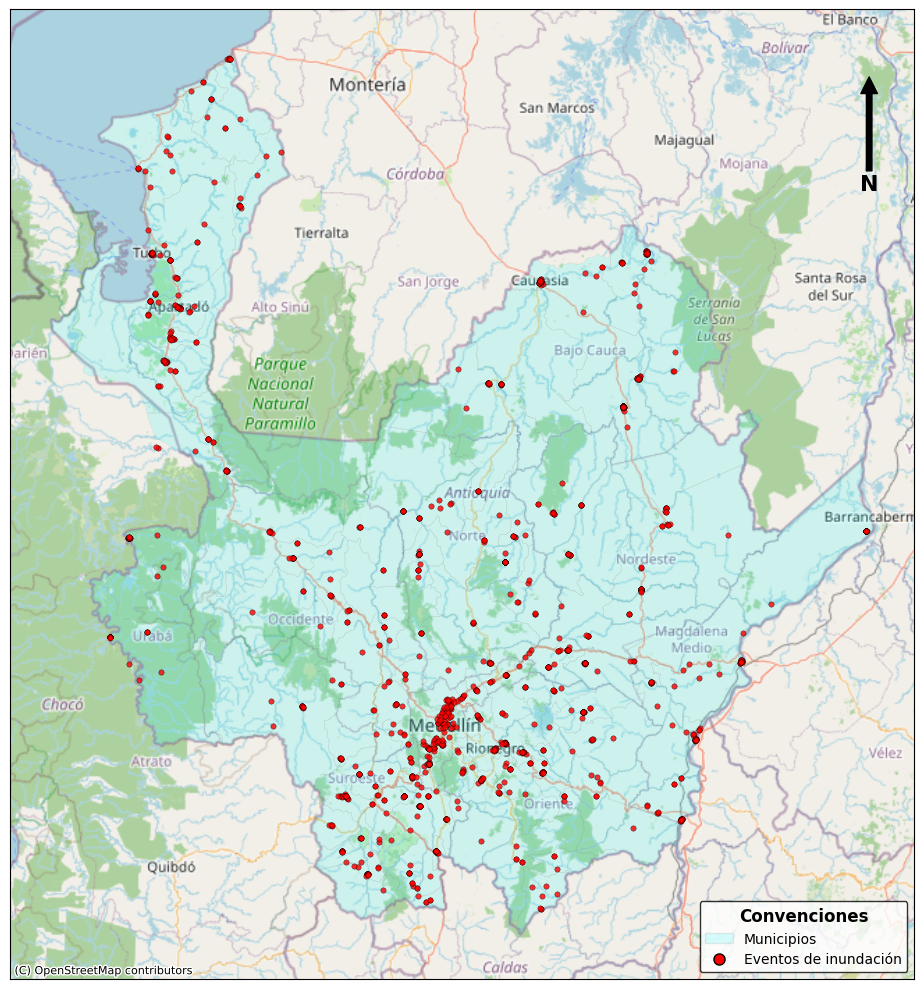

In [17]:
gdf_proyectado = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

municipios.plot(
    ax=ax,
    facecolor="cyan",
    edgecolor="gray",
    linewidth=0.4,
    alpha=0.15,
    label="Municpios",
    zorder=1
)

gdf_proyectado.plot(
    ax=ax, 
    markersize=15, 
    color='red',
    alpha=0.8,
    edgecolor='black',
    linewidth=0.3,
    label="Eventos de inundación",
    zorder=2
)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,    
    zoom=8,
    reset_extent=True
)
#ax.set_title('Distribución Espacial de Inundaciones', fontsize=16, fontweight='bold', pad=20)

ax.tick_params(
    axis='both', 
    which='both', 
    bottom=True, top=True, left=True, right=True, 
    labelbottom=True, labeltop=True, labelleft=True, labelright=True, 
    labelsize=8
)

#ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

for tick in ax.get_yticklabels():
    tick.set_rotation(90)
    tick.set_verticalalignment('center')

ax.annotate(
    "N",
    xy=(0.95, 0.93),      # Punta de la flecha
    xytext=(0.95, 0.82),  # Posición de la letra
    xycoords="axes fraction",
    textcoords="axes fraction",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        width=4,
        headwidth=12
    )
)

# ==========================
# Leyenda personalizada
# ==========================
legend_elements = [
    Patch(
        facecolor="cyan",
        edgecolor="gray",
        alpha=0.15,
        label="Municipios"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="red",
        markeredgecolor="black",
        markersize=8,
        label="Eventos de inundación"
    )
]

leg = ax.legend(
    handles=legend_elements,
    title="Convenciones",
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=10
)

# Tamaño y estilo del título
leg.get_title().set_fontsize(12)
leg.get_title().set_fontweight("bold")

ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

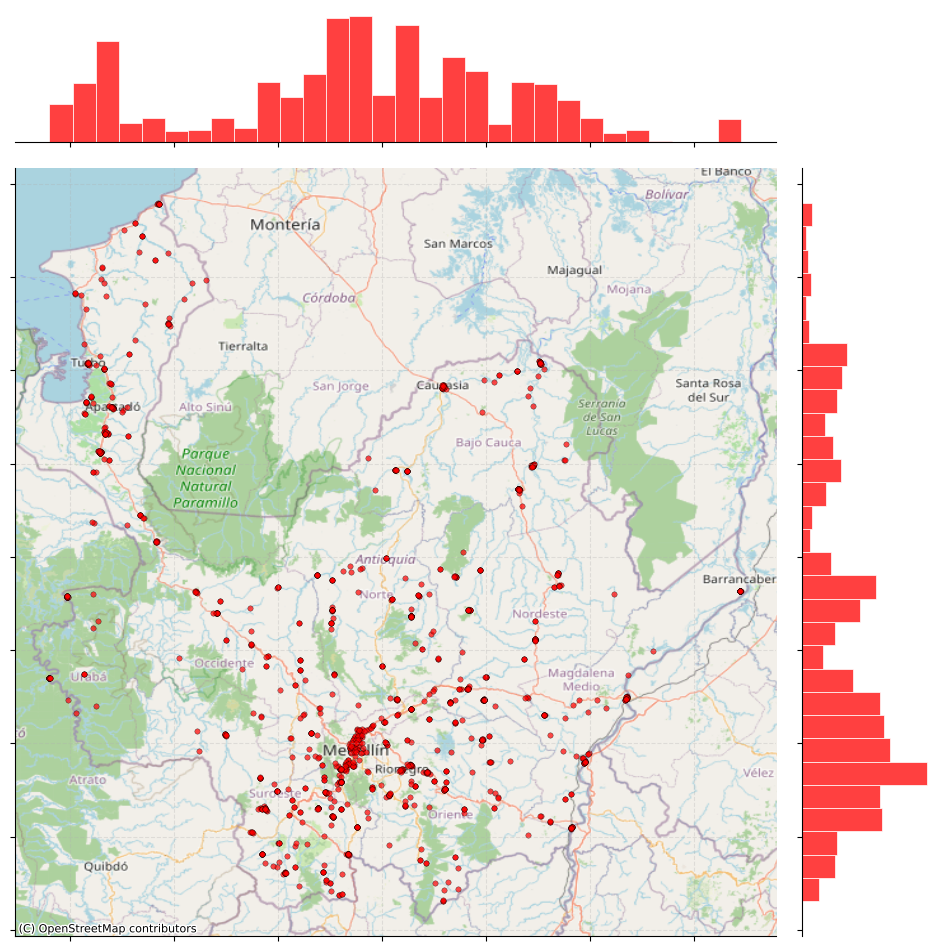

In [8]:
# 1. Asegurar proyección y extraer coordenadas en metros
gdf_proyectado = gdf.to_crs(epsg=3857)
df_coords = pd.DataFrame({
    'Coordenada X (m)': gdf_proyectado.geometry.x,
    'Coordenada Y (m)': gdf_proyectado.geometry.y
})

# 2. Generar el JointPlot configurando la cantidad de columnas (bins)
g = sns.jointplot(
    x='Coordenada X (m)', 
    y='Coordenada Y (m)', 
    data=df_coords, 
    kind='scatter',
    s=15,                 
    color='red', 
    alpha=0.7,
    edgecolor='black',
    linewidth=0.3,
    height=10,
    marginal_kws=dict(bins=30, edgecolor='white', linewidth=0.5) 
)

# 3. Añadir el mapa base de fondo ÚNICAMENTE al eje central
ctx.add_basemap(
    g.ax_joint, 
    source=ctx.providers.OpenStreetMap.Mapnik, 
    zorder=0
)

# =========================================================================
# 4. Formato estético, títulos y ROTACIÓN DEL EJE Y
# =========================================================================
g.ax_joint.set_title('Distribución Espacial de Inundaciones DAGRAN', fontsize=14, fontweight='bold', pad=90)
g.ax_joint.grid(True, linestyle='--', alpha=0.3)

g.ax_joint.set_xticklabels([])
g.ax_joint.set_yticklabels([])

g.ax_joint.set_xlabel("")
g.ax_joint.set_ylabel("")

plt.show()

Lado de cada celda configurado en: 20000.00 metros


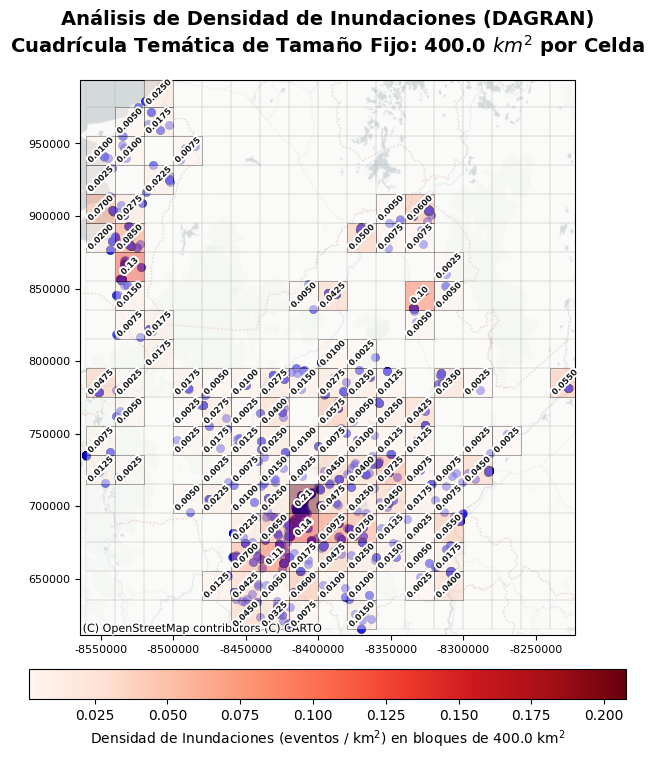

In [33]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import box
from matplotlib.ticker import FormatStrFormatter

# ==========================================
# 1. PARÁMETRO: DEFINIR EL TAMAÑO DE LA CELDA EN KM²
# ==========================================
# Define aquí el tamaño deseado para cada rectángulo EN KILÓMETROS CUADRADOS (km²)
# Nota: Tus 160,000 hectáreas anteriores equivalen exactamente a 1,600 km²
tamano_celda_km2 = 400.0  

# Convertimos los km² ingresados a metros cuadrados para la proyección (1 km² = 1,000,000 m²)
area_deseada_m2 = tamano_celda_km2 * 1_000_000
# Asumiendo cuadrantes perfectos: lado del cuadrado = raíz cuadrada del área en metros
lado_celda = np.sqrt(area_deseada_m2)
print(f"Lado de cada celda configurado en: {lado_celda:.2f} metros")

# Obtener límites del mapa del DAGRAN
xmin, ymin, xmax, ymax = gdf_proyectado.total_bounds

# Generar los pasos fijos basados en el tamaño en metros
rango_x = np.arange(xmin, xmax + lado_celda, lado_celda)
rango_y = np.arange(ymin, ymax + lado_celda, lado_celda)

# 2. Crear las celdas geométricas con el tamaño exacto asignado
celdas = []
for i in range(len(rango_x) - 1):
    for j in range(len(rango_y) - 1):
        x1 = rango_x[i]
        x2 = rango_x[i+1]
        y1 = rango_y[j]
        y2 = rango_y[j+1]
        celdas.append(box(x1, y1, x2, y2))

grid = gpd.GeoDataFrame({'geometry': celdas}, crs=gdf_proyectado.crs)

# 3. Intersección espacial y conteo de eventos
puntos_en_grid = gpd.sjoin(gdf_proyectado, grid, how='inner', predicate='within')
conteos = puntos_en_grid.groupby('index_right').size()
grid['conteo'] = grid.index.map(conteos).fillna(0).astype(int)

# ==========================================
# 4. CÁLCULO DE DENSIDAD REAL EN KM² (.area)
# ==========================================
# Calculamos el área real de cada celda convirtiendo sus metros cuadrados a km²
grid['area_km2'] = grid['geometry'].area / 1_000_000  

# Densidad = Eventos / Área real del cuadrado en km²
grid['densidad_km2'] = grid['conteo'] / grid['area_km2']
# ==========================================

# Separamos las celdas con datos de las vacías para una transparencia perfecta
grid_con_datos = grid[grid['conteo'] > 0]
grid_vacio = grid[grid['conteo'] == 0]

# 5. Configuración del mapa base y lienzo
fig, ax = plt.subplots(figsize=(11, 9), dpi=100)

# Graficar cuadrantes VACÍOS: Solo el borde, 100% transparentes por dentro
if not grid_vacio.empty:
    grid_vacio.plot(
        ax=ax,
        facecolor='none',
        edgecolor='#999999',
        linewidth=0.3,
        alpha=0.4,
        zorder=2
    )

# Graficar cuadrantes CON DATOS: Con opacidad controlada para conservar la visibilidad del mapa base
if not grid_con_datos.empty:
    grid_con_datos.plot(
        column='densidad_km2', 
        cmap='Reds', # Escala clásica de rojos para intensidades críticas      
        edgecolor='black',
        linewidth=0.5,
        alpha=0.45, # Alta transparencia para priorizar el fondo urbano
        ax=ax,
        legend=True,
        legend_kwds={
            'label': f"Densidad de Inundaciones (eventos / $\\text{{km}}^2$) en bloques de {tamano_celda_km2} $\\text{{km}}^2$", 
            'orientation': 'horizontal', 
            'pad': 0.05, 
            'shrink': 0.7
        },
        zorder=3
    )

# 6. Superponer los puntos reales del DAGRAN
tamanos = gdf_proyectado['PERSONAS_A'] * 0.005 + 15

ax.scatter(gdf_proyectado.geometry.x, gdf_proyectado.geometry.y, color='blue', alpha=0.5, edgecolor='black', linewidth=0.3, label='Eventos de Inundación', zorder=2)


# Agregar Mapa Base de fondo (Capa zorder=1)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zorder=1)

# 7. Agregar etiquetas en el centro de los cuadrantes activos

# =========================================================================
# 7. Agregar etiquetas en el centro de los cuadrantes activos con máscara/halo
# =========================================================================
for idx, row in grid_con_datos.iterrows():
    centroide = row['geometry'].centroid
    densidad_val = row['densidad_km2']
    
    # Formateo dinámico según la escala
    if densidad_val >= 0.1:
        texto_densidad = f"{densidad_val:.2f}"
    else:
        texto_densidad = f"{densidad_val:.4f}"
    
    ax.text(
        centroide.x, centroide.y, 
        texto_densidad, 
        ha='center', va='center', 
        fontsize=6,
        rotation=45,
        fontweight='bold',
        color='#1A1A1A',  # Color de la letra: Negro/Gris oscuro
        zorder=6,
        # Aplicamos el efecto de máscara (halo blanco alrededor del texto negro)
        path_effects=[
            patheffects.withStroke(linewidth=3, foreground='white')
        ]
    )
# 8. Formato final del lienzo
ax.set_title(f'Análisis de Densidad de Inundaciones (DAGRAN)\nCuadrícula Temática de Tamaño Fijo: {tamano_celda_km2} $km^2$ por Celda', fontsize=14, fontweight='bold', pad=20)

ax.set_xlim(xmin - lado_celda * 0.2, xmax + lado_celda * 0.2)
ax.set_ylim(ymin - lado_celda * 0.2, ymax + lado_celda * 0.2)

ax.tick_params(axis='both', labelsize=8)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

plt.show()

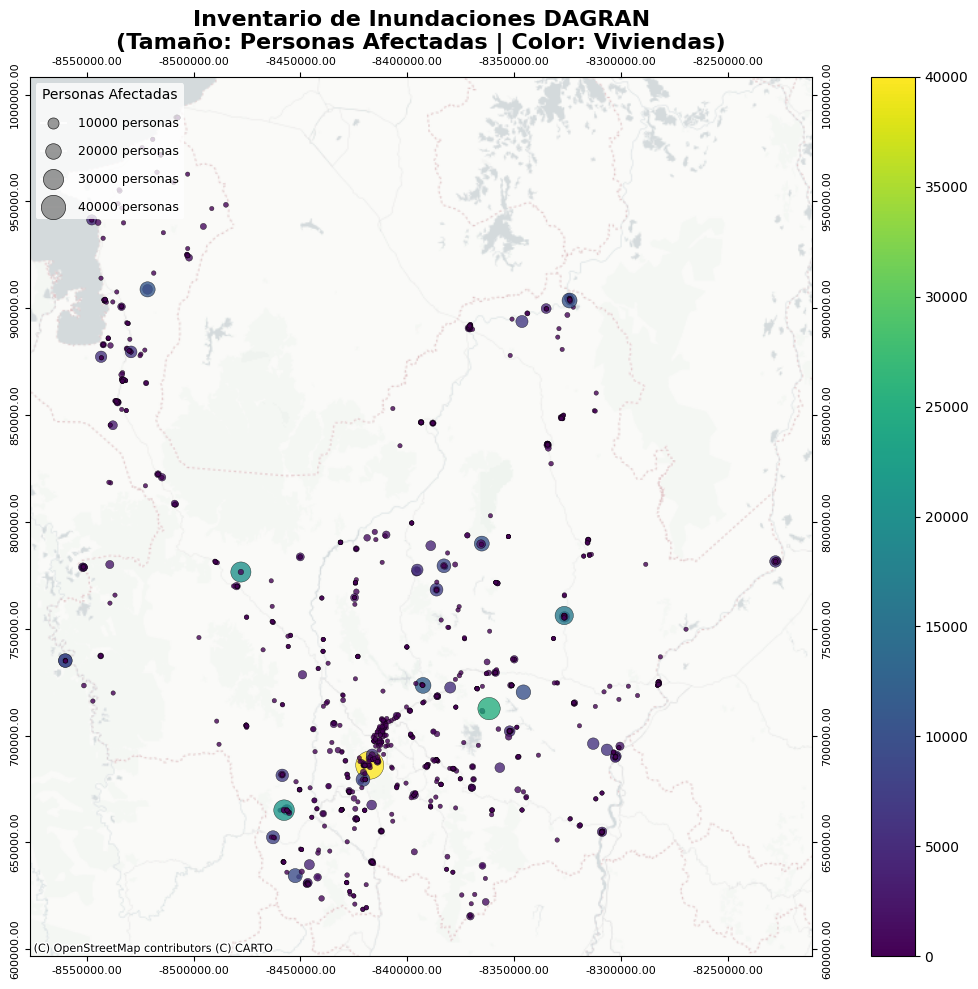

In [ ]:
tamanos = (gdf_proyectado['PERSONAS_A'] * 0.01) + 10
valores_referencia = [10000, 20000, 30000, 40000] 

tamanos_visuales_leyenda = [8, 11.2, 14.5, 17.5]

leyenda_tamanos = [
    Line2D([0], [0], marker='o', color='w', 
           label=f"{v} personas",
           markerfacecolor='gray', 
           markersize=tam_vis, # <-- Tamaño controlado para que quepa en el recuadro
           markeredgecolor='black', markeredgewidth=0.5, alpha=0.8)
    for v, tam_vis in zip(valores_referencia, tamanos_visuales_leyenda)
]

# --- Configuración de la Figura y el Mapa ---
fig, ax = plt.subplots(figsize=(12, 10))

# Graficar el mapa con la barra de color (VIVIENDASD)
gdf_proyectado.plot(
    ax=ax, 
    column='Area', 
    markersize=tamanos, # Mantiene tu escala original en el mapa
    alpha=0.8,
    edgecolor='black',
    linewidth=0.3,
    legend=True,
    zorder=2
)

# Añadir la leyenda de tamaños corregida
ax.legend(
    handles=leyenda_tamanos, 
    title="Personas Afectadas", 
    loc="upper left",          
    frameon=True,              
    facecolor='white',         
    edgecolor='none', 
    fontsize=9, 
    title_fontsize=10,
    labelspacing=1.2, # Añade un espacio cómodo entre cada fila de la leyenda
    handletextpad=1.0
)

# Agregar el mapa base de CartoDB
ctx.add_basemap(
    ax, 
    source=ctx.providers.CartoDB.PositronNoLabels, 
    zorder=1
)

ax.set_title('Inventario de Inundaciones DAGRAN\n(Tamaño: Personas Afectadas | Color: Viviendas)', fontsize=16, fontweight='bold', pad=20)

ax.tick_params(
    axis='both', 
    which='both', 
    bottom=True, top=True, left=True, right=True, 
    labelbottom=True, labeltop=True, labelleft=True, labelright=True, 
    labelsize=8
)

ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

for tick in ax.get_yticklabels():
    tick.set_rotation(90)
    tick.set_verticalalignment('center')

plt.tight_layout()
plt.show()

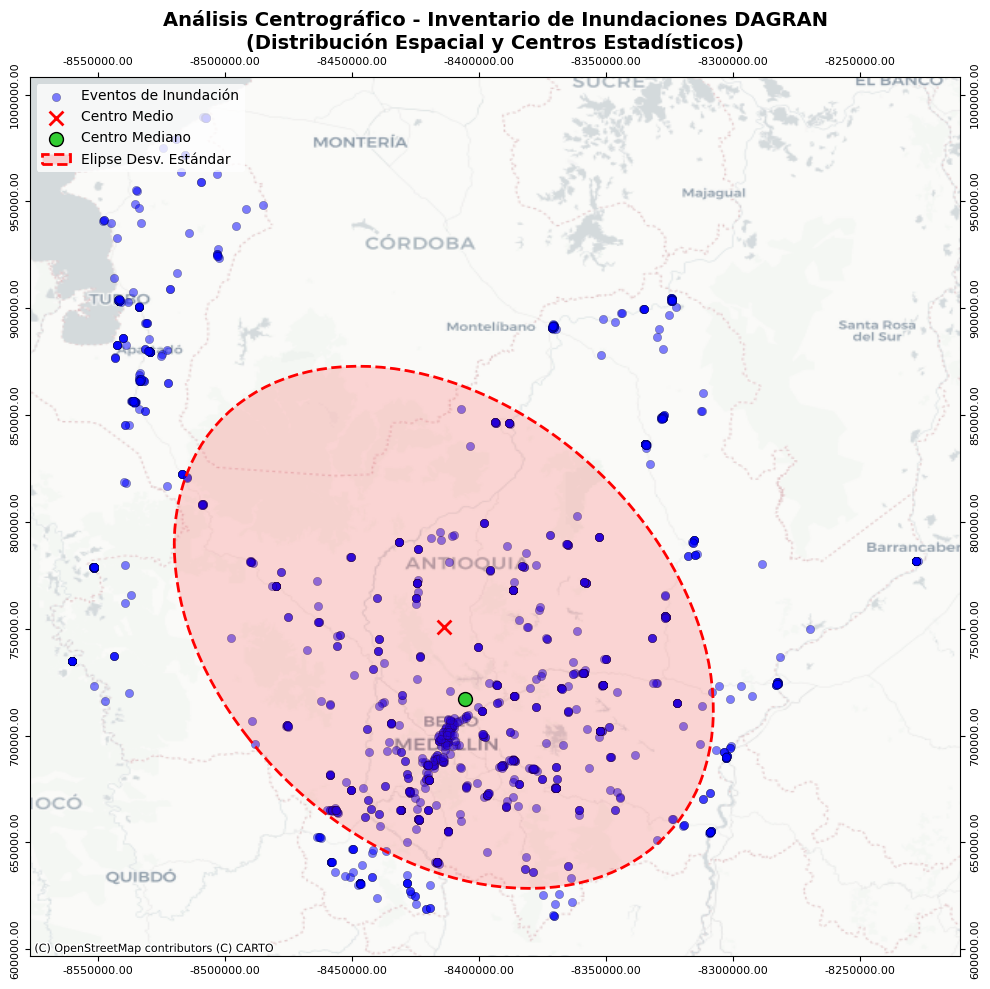

In [ ]:
coordenadas_xy = np.column_stack((gdf_proyectado.geometry.x, gdf_proyectado.geometry.y))
mean_center = centrography.mean_center(coordenadas_xy)
med_center = centrography.euclidean_median(coordenadas_xy)

major, minor, rotation = centrography.ellipse(coordenadas_xy)

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(gdf_proyectado.geometry.x, gdf_proyectado.geometry.y, color='blue', alpha=0.5, edgecolor='black', linewidth=0.3, label='Eventos de Inundación', zorder=2)

# Graficar el Centro Medio y Centro Mediano
ax.scatter(mean_center[0], mean_center[1], color='red', marker='x', s=100, linewidth=2, label='Centro Medio', zorder=4)
ax.scatter(med_center[0], med_center[1], color='limegreen', marker='o', s=100, edgecolor='black', label='Centro Mediano', zorder=4)


ellipse = Ellipse(
    xy=mean_center, 
    width=major * 2, 
    height=minor * 2, 
    angle=np.rad2deg(rotation), 
    facecolor=(1, 0, 0, 0.15),  # <-- Rojo claro translúcido (RGBA: 15% de opacidad)
    edgecolor='red', 
    linestyle='--', 
    linewidth=2,
    label='Elipse Desv. Estándar', 
    zorder=3
)
ax.add_patch(ellipse)

# Agregar mapa base
ctx.add_basemap(
    ax, 
    source=ctx.providers.CartoDB.Positron, 
    zorder=1
)

# --- 4. Formato Estético de Ejes (Consistente con tus mapas anteriores) ---
ax.set_title('Análisis Centrográfico - Inventario de Inundaciones DAGRAN\n(Distribución Espacial y Centros Estadísticos)', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(loc="upper left", frameon=True, facecolor='white', edgecolor='none')

ax.tick_params(
    axis='both', 
    which='both', 
    bottom=True, top=True, left=True, right=True, 
    labelbottom=True, labeltop=True, labelleft=True, labelright=True, 
    labelsize=8
)

ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

for tick in ax.get_yticklabels():
    tick.set_rotation(90)
    tick.set_verticalalignment('center')

plt.tight_layout()
plt.show()

El factor de bandwidth (Silverman) calculado es: 0.3038780842771358


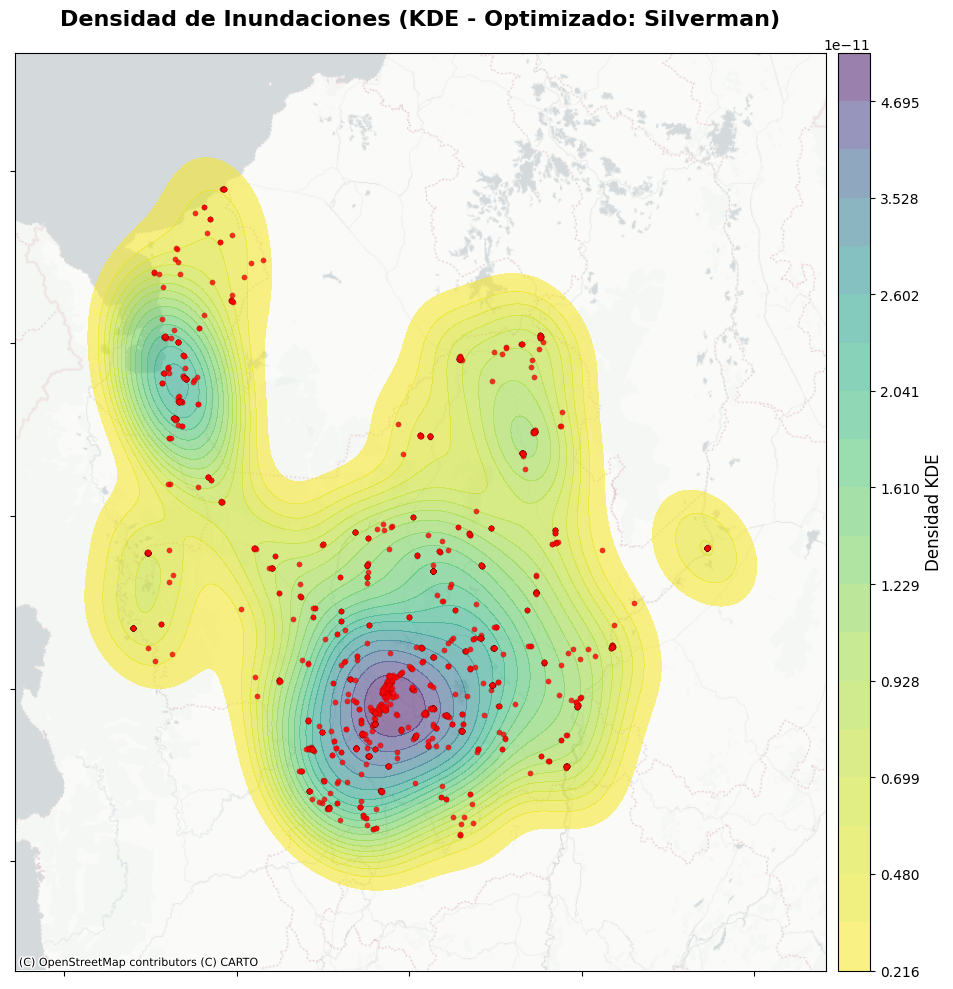

In [27]:
x = gdf_proyectado.geometry.x
y = gdf_proyectado.geometry.y

data = np.vstack([x, y])
kde = gaussian_kde(data, bw_method='silverman')

bandwidth_factor = kde.covariance_factor()

print(f"El factor de bandwidth (Silverman) calculado es: {bandwidth_factor}")

gdf_proyectado = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

x = gdf_proyectado.geometry.x
y = gdf_proyectado.geometry.y

# Se agregó ax=ax y zorder=2
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import seaborn as sns

# KDE
kde = sns.kdeplot(
    x=x,
    y=y,
    ax=ax,
    cmap="viridis_r",
    levels=20,
    bw_method="silverman",
    fill=True,
    alpha=0.55,
    zorder=2
)

# Eje lateral para la barra de color
divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.12
)

# Barra continua de color
cbar = plt.colorbar(
    kde.collections[-1],
    cax=cax
)

cbar.set_label(
    "Densidad KDE",
    fontsize=12
)

cbar.ax.tick_params(
    labelsize=10
)

# Se corrigió 'turquiose' a 'turquoise' y se agregó zorder=3
gdf_proyectado.plot(
    ax=ax,  
    markersize=15, 
    alpha=0.8,
    color='red',
    edgecolor="black",
    linewidth=0.1,
    zorder=3
)

ctx.add_basemap(
    ax, 
    source=ctx.providers.CartoDB.PositronNoLabels, 
    zorder=1
)

ax.set_title('Densidad de Inundaciones (KDE - Optimizado: Silverman)', fontsize=16, fontweight='bold', pad=20)

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels([])
ax.set_yticklabels([])
plt.tight_layout()
plt.show()

Lado de cada celda configurado en: 20000.00 metros


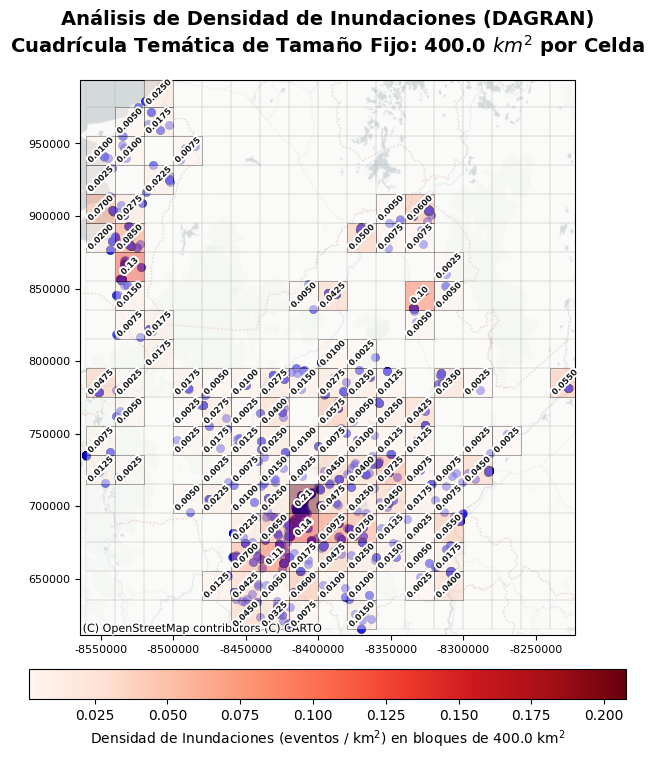

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import box
from matplotlib.ticker import FormatStrFormatter

# ==========================================
# 1. PARÁMETRO: DEFINIR EL TAMAÑO DE LA CELDA EN KM²
# ==========================================
# Define aquí el tamaño deseado para cada rectángulo EN KILÓMETROS CUADRADOS (km²)
# Nota: Tus 160,000 hectáreas anteriores equivalen exactamente a 1,600 km²
tamano_celda_km2 = 400.0  

# Convertimos los km² ingresados a metros cuadrados para la proyección (1 km² = 1,000,000 m²)
area_deseada_m2 = tamano_celda_km2 * 1_000_000
# Asumiendo cuadrantes perfectos: lado del cuadrado = raíz cuadrada del área en metros
lado_celda = np.sqrt(area_deseada_m2)
print(f"Lado de cada celda configurado en: {lado_celda:.2f} metros")

# Obtener límites del mapa del DAGRAN
xmin, ymin, xmax, ymax = gdf_proyectado.total_bounds

# Generar los pasos fijos basados en el tamaño en metros
rango_x = np.arange(xmin, xmax + lado_celda, lado_celda)
rango_y = np.arange(ymin, ymax + lado_celda, lado_celda)

# 2. Crear las celdas geométricas con el tamaño exacto asignado
celdas = []
for i in range(len(rango_x) - 1):
    for j in range(len(rango_y) - 1):
        x1 = rango_x[i]
        x2 = rango_x[i+1]
        y1 = rango_y[j]
        y2 = rango_y[j+1]
        celdas.append(box(x1, y1, x2, y2))

grid = gpd.GeoDataFrame({'geometry': celdas}, crs=gdf_proyectado.crs)

# 3. Intersección espacial y conteo de eventos
puntos_en_grid = gpd.sjoin(gdf_proyectado, grid, how='inner', predicate='within')
conteos = puntos_en_grid.groupby('index_right').size()
grid['conteo'] = grid.index.map(conteos).fillna(0).astype(int)

# ==========================================
# 4. CÁLCULO DE DENSIDAD REAL EN KM² (.area)
# ==========================================
# Calculamos el área real de cada celda convirtiendo sus metros cuadrados a km²
grid['area_km2'] = grid['geometry'].area / 1_000_000  

# Densidad = Eventos / Área real del cuadrado en km²
grid['densidad_km2'] = grid['conteo'] / grid['area_km2']
# ==========================================

# Separamos las celdas con datos de las vacías para una transparencia perfecta
grid_con_datos = grid[grid['conteo'] > 0]
grid_vacio = grid[grid['conteo'] == 0]

# 5. Configuración del mapa base y lienzo
fig, ax = plt.subplots(figsize=(11, 9), dpi=100)

# Graficar cuadrantes VACÍOS: Solo el borde, 100% transparentes por dentro
if not grid_vacio.empty:
    grid_vacio.plot(
        ax=ax,
        facecolor='none',
        edgecolor='#999999',
        linewidth=0.3,
        alpha=0.4,
        zorder=2
    )

# Graficar cuadrantes CON DATOS: Con opacidad controlada para conservar la visibilidad del mapa base
if not grid_con_datos.empty:
    grid_con_datos.plot(
        column='densidad_km2', 
        cmap='Reds', # Escala clásica de rojos para intensidades críticas      
        edgecolor='black',
        linewidth=0.5,
        alpha=0.45, # Alta transparencia para priorizar el fondo urbano
        ax=ax,
        legend=True,
        legend_kwds={
            'label': f"Densidad de Inundaciones (eventos / $\\text{{km}}^2$) en bloques de {tamano_celda_km2} $\\text{{km}}^2$", 
            'orientation': 'horizontal', 
            'pad': 0.05, 
            'shrink': 0.7
        },
        zorder=3
    )

# 6. Superponer los puntos reales del DAGRAN
tamanos = gdf_proyectado['PERSONAS_A'] * 0.005 + 15

ax.scatter(gdf_proyectado.geometry.x, gdf_proyectado.geometry.y, color='blue', alpha=0.5, edgecolor='black', linewidth=0.3, label='Eventos de Inundación', zorder=2)


# Agregar Mapa Base de fondo (Capa zorder=1)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zorder=1)

# 7. Agregar etiquetas en el centro de los cuadrantes activos

# =========================================================================
# 7. Agregar etiquetas en el centro de los cuadrantes activos con máscara/halo
# =========================================================================
for idx, row in grid_con_datos.iterrows():
    centroide = row['geometry'].centroid
    densidad_val = row['densidad_km2']
    
    # Formateo dinámico según la escala
    if densidad_val >= 0.1:
        texto_densidad = f"{densidad_val:.2f}"
    else:
        texto_densidad = f"{densidad_val:.4f}"
    
    ax.text(
        centroide.x, centroide.y, 
        texto_densidad, 
        ha='center', va='center', 
        fontsize=6,
        rotation=45,
        fontweight='bold',
        color='#1A1A1A',  # Color de la letra: Negro/Gris oscuro
        zorder=6,
        # Aplicamos el efecto de máscara (halo blanco alrededor del texto negro)
        path_effects=[
            patheffects.withStroke(linewidth=3, foreground='white')
        ]
    )
# 8. Formato final del lienzo
ax.set_title(f'Análisis de Densidad de Inundaciones (DAGRAN)\nCuadrícula Temática de Tamaño Fijo: {tamano_celda_km2} $km^2$ por Celda', fontsize=14, fontweight='bold', pad=20)

ax.set_xlim(xmin - lado_celda * 0.2, xmax + lado_celda * 0.2)
ax.set_ylim(ymin - lado_celda * 0.2, ymax + lado_celda * 0.2)

ax.tick_params(axis='both', labelsize=8)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

plt.show()

Lado de celda Silverman: 24509.45 m
Área aproximada de celda: 600.71 km²


C:\Users\juand\AppData\Local\Temp\ipykernel_4172\1556908274.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


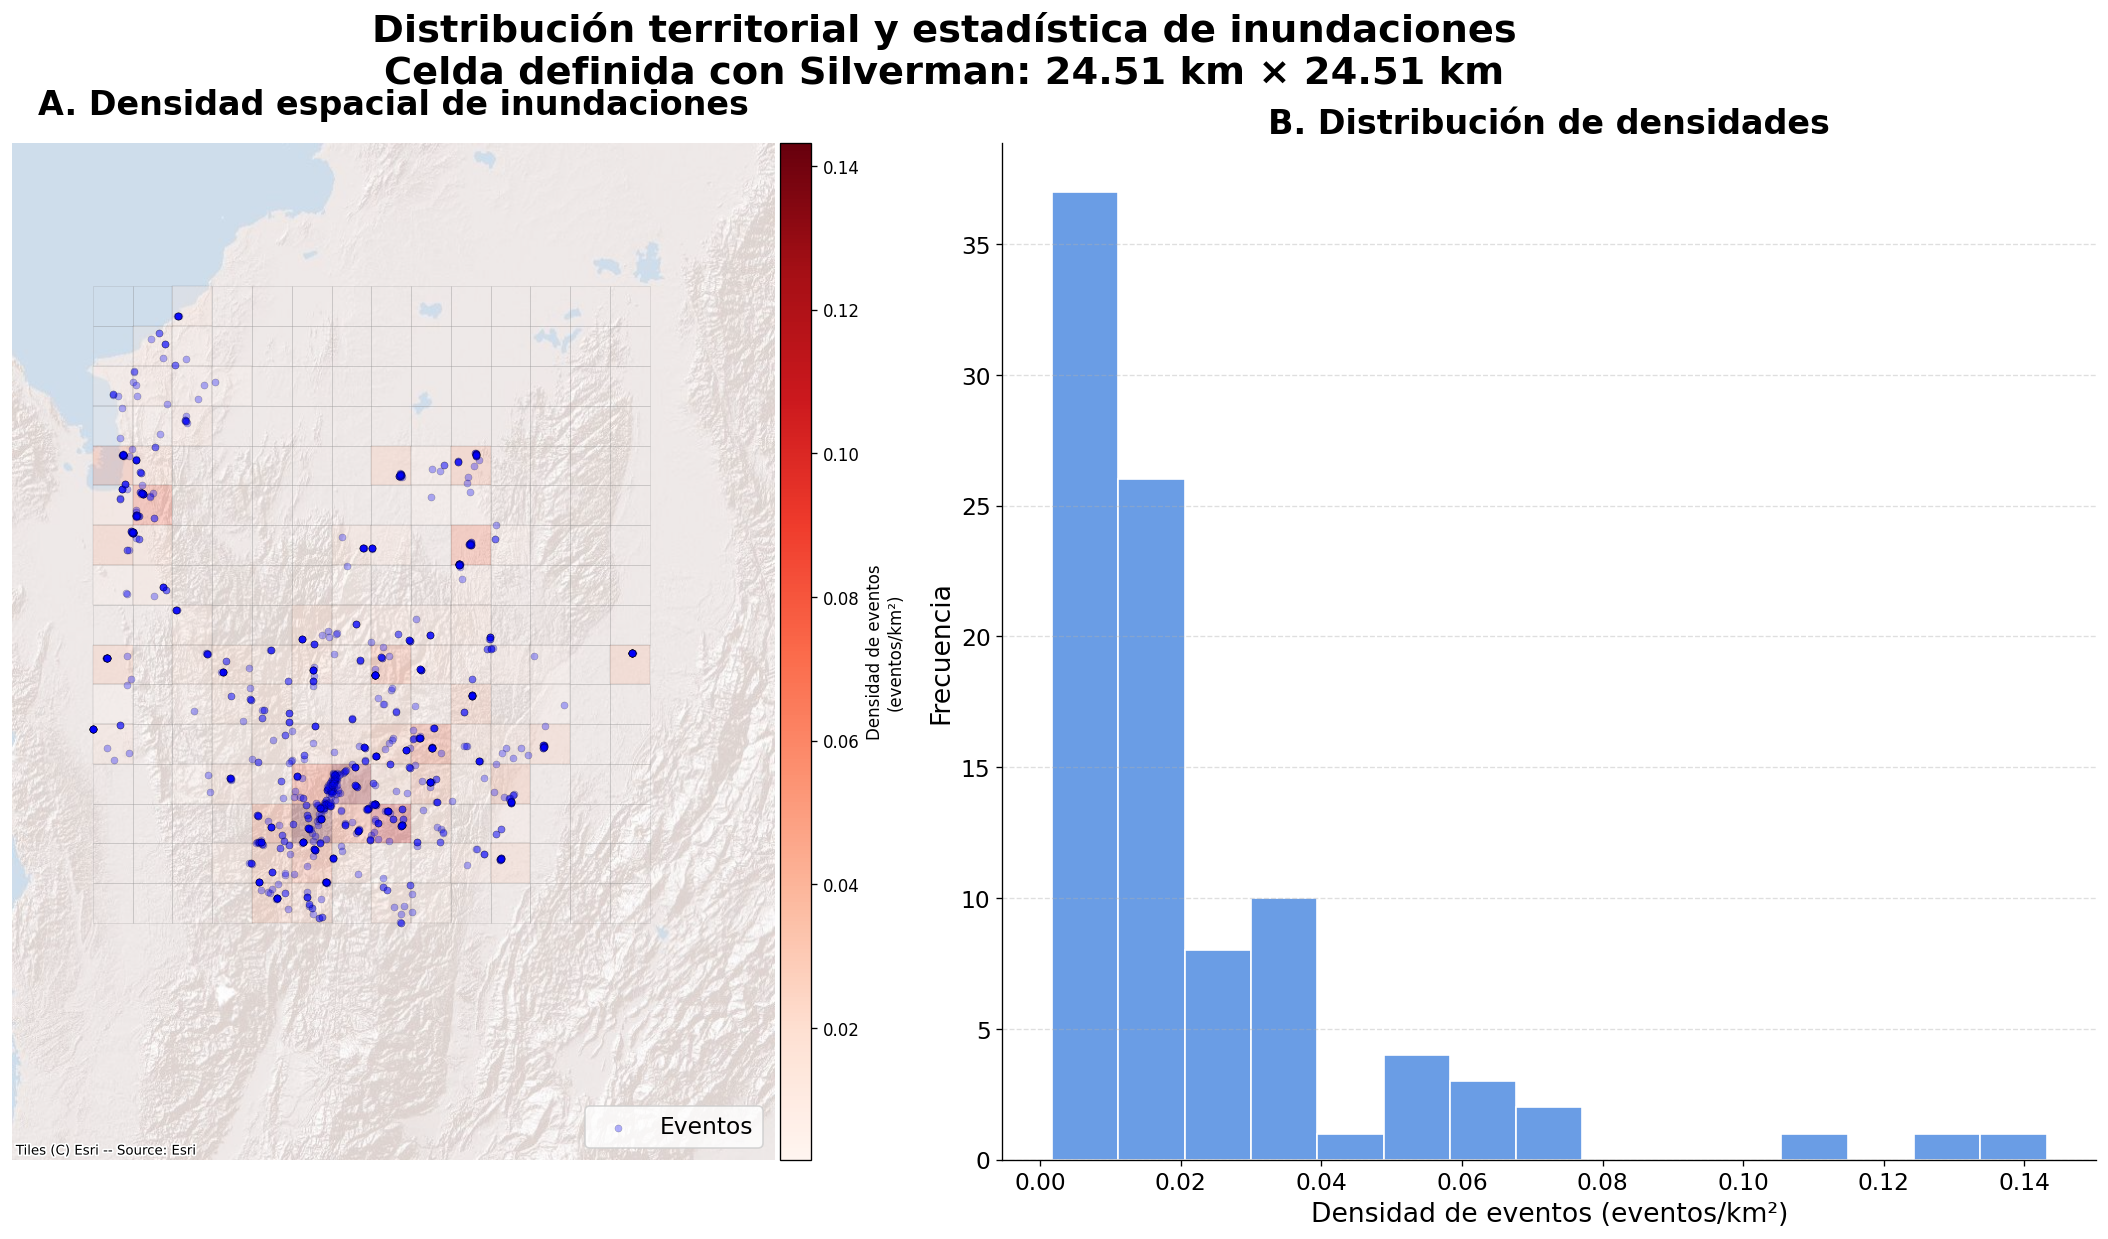

In [26]:
from shapely.geometry import box
from mpl_toolkits.axes_grid1 import make_axes_locatable

gdf_proyectado = gdf.to_crs(epsg=3857)

x = gdf_proyectado.geometry.x.values
y = gdf_proyectado.geometry.y.values
n = len(gdf_proyectado)

# ==========================
# Distancia de Silverman 2D
# h = sigma * n^(-1/6)
# ==========================
sigma = np.mean([np.std(x), np.std(y)])
lado_celda = sigma * n ** (-1 / 6)

tamano_celda_km2 = (lado_celda ** 2) / 1_000_000

print(f"Lado de celda Silverman: {lado_celda:.2f} m")
print(f"Área aproximada de celda: {tamano_celda_km2:.2f} km²")

# ==========================
# Crear grid
# ==========================
xmin, ymin, xmax, ymax = gdf_proyectado.total_bounds

xs = np.arange(xmin, xmax + lado_celda, lado_celda)
ys = np.arange(ymin, ymax + lado_celda, lado_celda)

grid = gpd.GeoDataFrame(
    geometry=[
        box(x1, y1, x1 + lado_celda, y1 + lado_celda)
        for x1 in xs[:-1]
        for y1 in ys[:-1]
    ],
    crs=gdf_proyectado.crs
)

# ==========================
# Conteo y densidad
# ==========================
join = gpd.sjoin(gdf_proyectado, grid, how="inner", predicate="within")
conteos = join.groupby("index_right").size()

grid["conteo"] = grid.index.map(conteos).fillna(0).astype(int)
grid["densidad_km2"] = grid["conteo"] / (grid.geometry.area / 1_000_000)

grid_datos = grid[grid["conteo"] > 0]
grid_vacio = grid[grid["conteo"] == 0]

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==========================
# Figura
# ==========================
fig, (ax_mapa, ax_histo) = plt.subplots(
    1, 2,
    figsize=(24, 11),
    dpi=120,
    gridspec_kw={
        "width_ratios": [1, 1],
        "wspace": 0.04
    }
)

# ==========================
# Grid vacío
# ==========================
grid_vacio.plot(
    ax=ax_mapa,
    facecolor="none",
    edgecolor="gray",
    linewidth=0.3,
    alpha=0.35,
    zorder=2
)

# ==========================
# Leyenda lateral
# ==========================
divider = make_axes_locatable(ax_mapa)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.05
)

# ==========================
# Grid con datos
# ==========================
grid_datos.plot(
    ax=ax_mapa,
    column="densidad_km2",
    cmap="Reds",
    edgecolor="black",
    linewidth=0.25,

    # Transparencia para conservar visible el relieve
    alpha=0.25,

    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Densidad de eventos\n(eventos/km²)"
    },
    zorder=3
)

# ==========================
# Puntos
# ==========================
gdf_proyectado.plot(
    ax=ax_mapa,
    color="blue",
    markersize=18,
    alpha=0.3,
    edgecolor="black",
    linewidth=0.3,
    label="Eventos",
    zorder=4
)

# ==========================
# Extensión correcta del mapa
# ==========================
ax_mapa.set_xlim(
    xmin - lado_celda,
    xmax + lado_celda
)

ax_mapa.set_ylim(
    ymin - lado_celda,
    ymax + lado_celda
)

# ==========================
# Mapa base
# Debe agregarse después de fijar la extensión
# ==========================
ctx.add_basemap(
    ax_mapa,
    source=ctx.providers.Esri.WorldShadedRelief,
    zoom="auto",
    reset_extent=False,
    alpha=0.5,
    zorder=0
)

ax_mapa.set_title(
    "A. Densidad espacial de inundaciones",
    fontsize=20,
    fontweight="bold"
)

ax_mapa.set_axis_off()

ax_mapa.legend(
    loc="lower right",
    fontsize=14,
    frameon=True
)

# ==========================
# Histograma
# ==========================
sns.histplot(
    grid_datos["densidad_km2"],
    bins=15,
    color="#4585DF",
    edgecolor="white",
    alpha=0.8,
    ax=ax_histo
)

ax_histo.set_title(
    "B. Distribución de densidades",
    fontsize=20,
    fontweight="bold"
)

ax_histo.set_xlabel(
    "Densidad de eventos (eventos/km²)",
    fontsize=16
)

ax_histo.set_ylabel(
    "Frecuencia",
    fontsize=16
)

ax_histo.tick_params(
    axis="both",
    labelsize=14
)

ax_histo.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

sns.despine(ax=ax_histo)

plt.suptitle(
    f"Distribución territorial y estadística de inundaciones\n"
    f"Celda definida con Silverman: "
    f"{lado_celda/1000:.2f} km × {lado_celda/1000:.2f} km",
    fontsize=23,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

plt.show()

In [35]:
grid.describe()

,conteo,densidad_km2
count,224.000000,224.000000
mean,5.602679,0.009327
std,12.142214,0.020213
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,7.000000,0.011653
max,86.000000,0.143163


Chi-cuadrado: 12777.0866 | P-value: 0.0000e+00


ConnectTimeout: HTTPSConnectionPool(host='a.basemaps.cartocdn.com', port=443): Max retries exceeded with url: /light_nolabels/8/74/122.png (Caused by ConnectTimeoutError(<HTTPSConnection(host='a.basemaps.cartocdn.com', port=443) at 0x2e23e556e90>, 'Connection to a.basemaps.cartocdn.com timed out. (connect timeout=None)'))

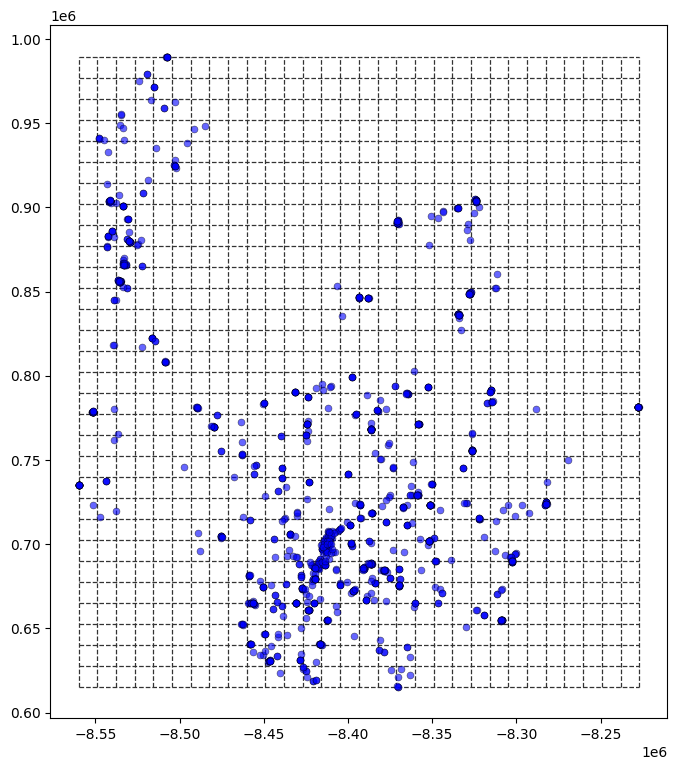

In [9]:
gdf_proyectado = gdf.to_crs(epsg=3857)
coordenadas = np.column_stack((gdf_proyectado.geometry.x, gdf_proyectado.geometry.y))

# Definición de cuadrantes
nx_div = 30
ny_div = 30
qstat = QStatistic(coordenadas, nx=nx_div, ny=ny_div)

# Imprimir resultados en consola
print("====================================================")
print(f"Chi-cuadrado: {qstat.chi2:.4f} | P-value: {qstat.chi2_pvalue:.4e}")
print("====================================================")

# =========================================================================
# 2. DISEÑO DEL MAPA (Cálculo geométrico independiente y seguro)
# =========================================================================
fig, ax = plt.subplots(figsize=(11, 9), dpi=100)

# A. Dibujar los puntos reales del DAGRAN
gdf_proyectado.plot(
    ax=ax,
    markersize=25,
    color='blue',
    alpha=0.6,
    edgecolor='black',
    linewidth=0.4,
    label='Eventos de Inundación',
    zorder=3
)

# B. GENERAR LA CUADRÍCULA DIRECTAMENTE DESDE LOS LÍMITES TOTALES
xmin, ymin, xmax, ymax = gdf_proyectado.total_bounds

# Creamos los cortes exactos en X e Y de forma síncrona con el número de divisiones
edges_x = np.linspace(xmin, xmax, nx_div + 1)
edges_y = np.linspace(ymin, ymax, ny_div + 1)

# Construir las líneas vectorizadas para la visualización de la grilla
lineas = []
for x in edges_x:
    lineas.append([(x, ymin), (x, ymax)])
for y in edges_y:
    lineas.append([(xmin, y), (xmax, y)])

grid_lines = LineCollection(lineas, colors='#333333', linewidths=0.9, linestyles='--', zorder=2)
ax.add_collection(grid_lines)

# C. Agregar el Mapa Base de fondo
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zorder=1)

# =========================================================================
# 3. FORMATO FINAL DEL LIENZO
# =========================================================================
ax.set_title(
    f'Análisis por Cuadrantes DAGRAN (QStatistic)\n'
    f'Cuadrícula: {nx_div}x{ny_div} | $\\chi^2$ P-value: {qstat.chi2_pvalue:.6f}', 
    fontsize=13, fontweight='bold', pad=20
)

# Configurar límites del mapa con un margen del 5% para que respire
pad_x = (xmax - xmin) * 0.05
pad_y = (ymax - ymin) * 0.05
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# Formato de etiquetas de coordenadas limpias (sin decimales innecesarios)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.tick_params(axis='both', labelsize=8)
ax.grid(False) 

plt.tight_layout()
plt.show()

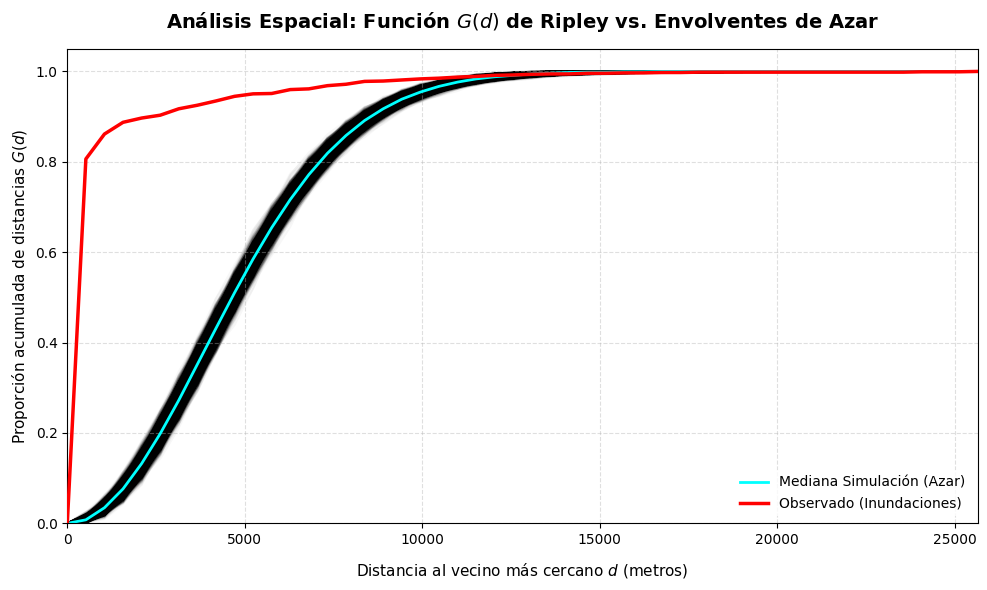

In [ ]:
gdf_ON = gdf.to_crs(epsg=9377)

coordenadas = np.column_stack((gdf_ON.geometry.x, gdf_ON.geometry.y))
g_test = distance_statistics.g_test(coordenadas, support=50, keep_simulations=True)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

ax.plot(g_test.support, g_test.simulations.T, color='k', alpha=0.03, zorder=1)

ax.plot(g_test.support, np.median(g_test.simulations, axis=0), 
        color='cyan', linewidth=2, label='Mediana Simulación (Azar)', zorder=2)

ax.plot(g_test.support, g_test.statistic, 
        color='red', linewidth=2.5, label='Observado (Inundaciones)', zorder=3)

ax.set_title("Análisis Espacial: Función $G(d)$ de Ripley vs. Envolventes de Azar", 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Distancia al vecino más cercano $d$ (metros)', fontsize=11, labelpad=10)
ax.set_ylabel('Proporción acumulada de distancias $G(d)$', fontsize=11)

ax.set_xlim(0, g_test.support.max())
ax.set_ylim(0, 1.05)

# Detalles finales de la grilla y leyenda
ax.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

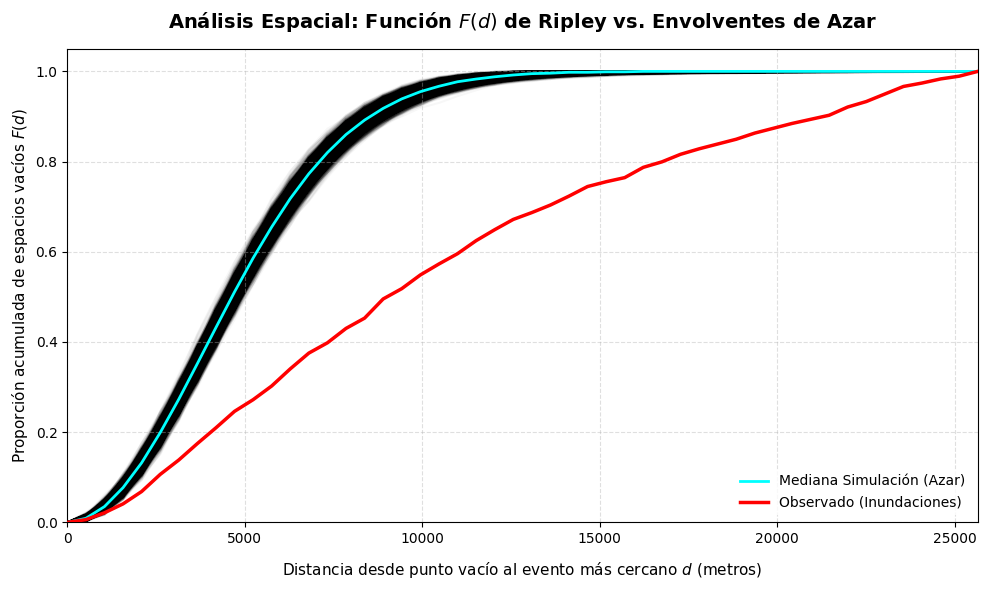

In [5]:
f_test = distance_statistics.f_test(coordenadas, support=50, keep_simulations=True)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Graficar las líneas de las simulaciones aleatorias (Envolventes de fondo CSR)
ax.plot(f_test.support, f_test.simulations.T, color='k', alpha=0.03, zorder=1)

# Mostrar la mediana de las simulaciones aleatorias (Patrón esperado por azar)
ax.plot(f_test.support, np.median(f_test.simulations, axis=0), 
        color='cyan', linewidth=2, label='Mediana Simulación (Azar)', zorder=2)

# Graficar la curva empírica observada (Datos reales de inundación DAGRAN)
ax.plot(f_test.support, f_test.statistic, 
        color='red', linewidth=2.5, label='Observado (Inundaciones)', zorder=3)

ax.set_title("Análisis Espacial: Función $F(d)$ de Ripley vs. Envolventes de Azar", 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Distancia desde punto vacío al evento más cercano $d$ (metros)', fontsize=11, labelpad=10)
ax.set_ylabel('Proporción acumulada de espacios vacíos $F(d)$', fontsize=11)

# Forzar los límites dinámicos en metros para tus datos
ax.set_xlim(0, f_test.support.max())
ax.set_ylim(0, 1.05)

# Detalles finales de la grilla y leyenda
ax.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

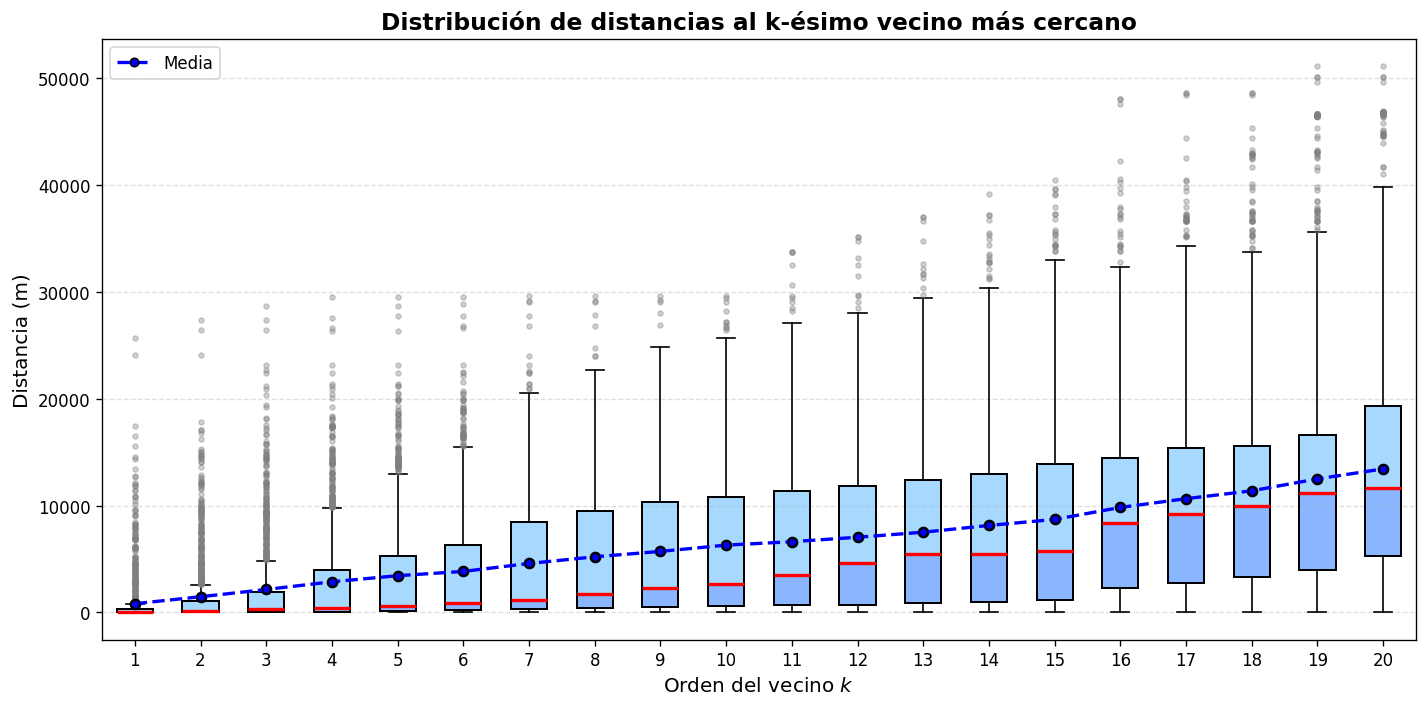

     k     Media   Mediana  Separacion  Desv.Est.       Q1        Q3  \
0    1    810.76      0.00      810.76    2338.55     0.00    316.71   
1    2   1462.10    162.64     1299.46    3135.55     0.00   1037.46   
2    3   2142.75    341.71     1801.04    4003.08     0.00   1934.18   
3    4   2861.41    435.04     2426.37    4648.23     2.50   3929.74   
4    5   3431.57    593.03     2838.54    5089.25   125.68   5244.70   
5    6   3832.46    843.37     2989.09    5384.86   243.78   6346.52   
6    7   4575.74   1134.31     3441.43    5778.54   321.82   8459.27   
7    8   5199.69   1680.14     3519.55    6031.27   381.10   9481.88   
8    9   5706.50   2288.80     3417.69    6253.12   540.64  10352.45   
9   10   6294.11   2699.44     3594.67    6746.96   610.15  10787.11   
10  11   6613.81   3519.57     3094.24    7039.71   651.55  11324.00   
11  12   7031.35   4577.43     2453.92    7271.55   731.86  11830.32   
12  13   7502.53   5475.15     2027.38    7470.45   893.86  1234

In [33]:
from scipy.spatial.distance import cdist
from matplotlib.patches import Rectangle
import numpy as np
import matplotlib.pyplot as plt

matriz_distancias = cdist(coordenadas, coordenadas)
distancias_ordenadas = np.sort(matriz_distancias, axis=1)

max_k = 20
valores_k = np.arange(1, max_k + 1)

datos_boxplot = [
    distancias_ordenadas[:, k]
    for k in valores_k
]

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bp = ax.boxplot(
    datos_boxplot,
    positions=valores_k,
    widths=0.55,
    patch_artist=True,
    showmeans=True,
    meanline=False,
    showfliers=True,

    boxprops=dict(
        facecolor="none",
        edgecolor="black",
        linewidth=1.2
    ),

    medianprops=dict(
        color="red",
        linewidth=2
    ),

    meanprops=dict(
        marker="o",
        markerfacecolor="blue",
        markeredgecolor="black",
        markersize=6
    ),

    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),

    flierprops=dict(
        marker="o",
        markersize=3,
        markerfacecolor="gray",
        markeredgecolor="gray",
        alpha=0.35
    )
)

color_inf = "#146EFF"
color_sup = "#51B4FF"

for box, med in zip(bp["boxes"], bp["medians"]):
    verts = box.get_path().vertices

    x0 = verts[:, 0].min()
    x1 = verts[:, 0].max()
    y0 = verts[:, 1].min()
    y1 = verts[:, 1].max()
    ymed = med.get_ydata()[0]

    ax.add_patch(
        Rectangle(
            (x0, y0),
            x1 - x0,
            ymed - y0,
            facecolor=color_inf,
            edgecolor="none",
            alpha=0.5,
            zorder=0
        )
    )

    ax.add_patch(
        Rectangle(
            (x0, ymed),
            x1 - x0,
            y1 - ymed,
            facecolor=color_sup,
            edgecolor="none",
            alpha=0.5,
            zorder=0
        )
    )

# ==========================================
# Unir las medias con una línea punteada azul
# ==========================================
medias = [
    mean.get_ydata()[0]
    for mean in bp["means"]
]

ax.plot(
    valores_k,
    medias,
    linestyle="--",
    linewidth=2,
    color="blue",
    marker="o",
    markersize=5,
    markerfacecolor="blue",
    markeredgecolor="black",
    zorder=5,
    label="Media"
)

ax.legend(loc="upper left")

ax.set_title(
    "Distribución de distancias al k-ésimo vecino más cercano",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Orden del vecino $k$", fontsize=12)
ax.set_ylabel("Distancia (m)", fontsize=12)

ax.set_xticks(valores_k)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np

resumen = pd.DataFrame({
    "k": valores_k,
    "Media": [np.mean(distancias_ordenadas[:, k]) for k in valores_k],
    "Mediana": [np.median(distancias_ordenadas[:, k]) for k in valores_k],
    "Separacion": [np.mean(distancias_ordenadas[:, k])-np.median(distancias_ordenadas[:, k]) for k in valores_k],
    "Desv.Est.": [np.std(distancias_ordenadas[:, k], ddof=1) for k in valores_k],
    "Mínimo": [np.min(distancias_ordenadas[:, k]) for k in valores_k],
    "Q1": [np.percentile(distancias_ordenadas[:, k], 25) for k in valores_k],
    "Q3": [np.percentile(distancias_ordenadas[:, k], 75) for k in valores_k],
    "Máximo": [np.max(distancias_ordenadas[:, k]) for k in valores_k],
})

resumen["RIC"] = resumen["Q3"] - resumen["Q1"]

resumen = resumen[
    ["k", "Media", "Mediana", "Separacion", "Desv.Est.", "Q1", "Q3", "RIC", "Mínimo", "Máximo"]
].round(2)

print(resumen)

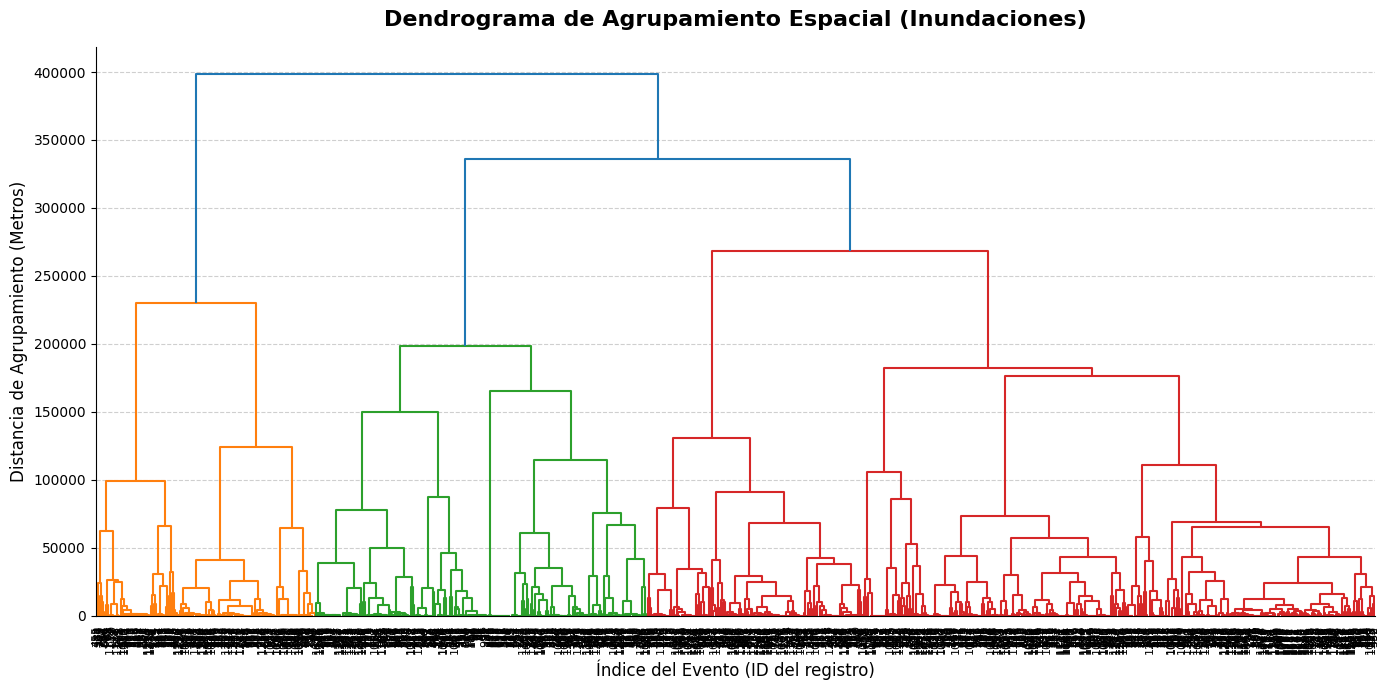

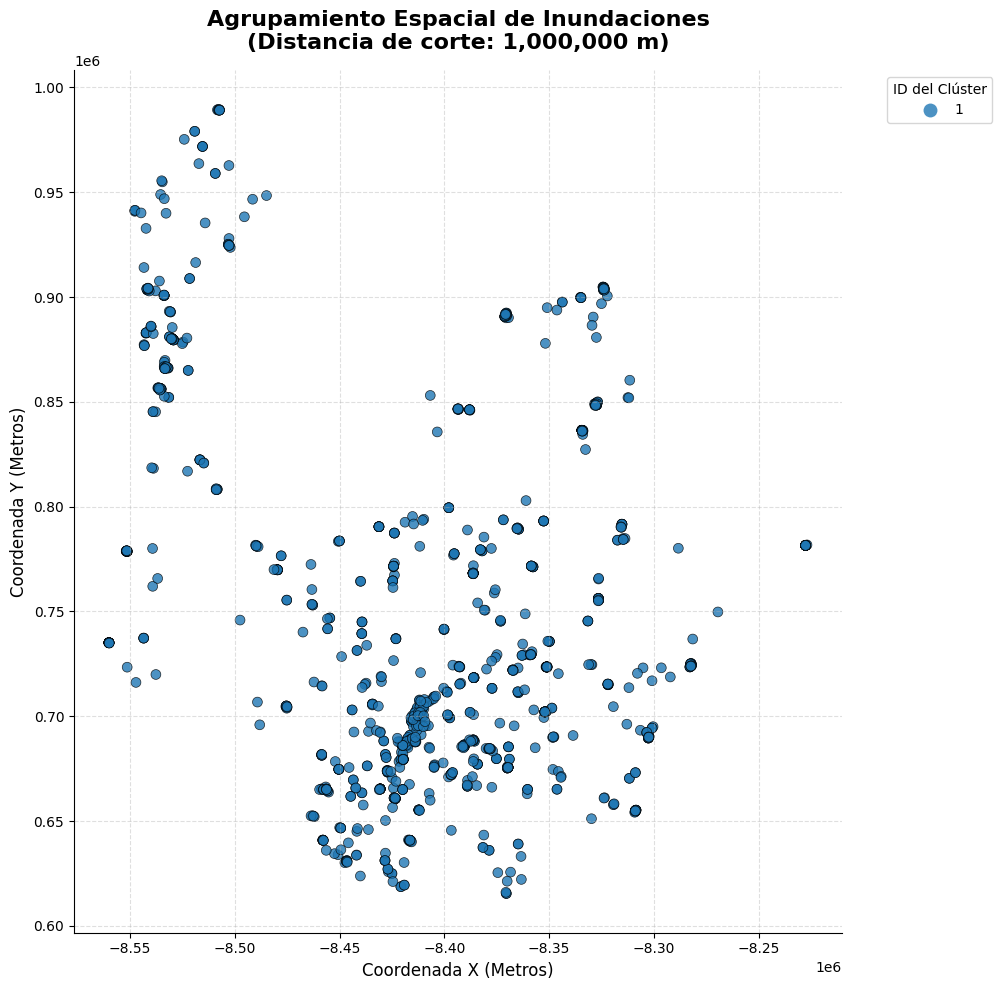

Distribución de eventos por clúster:
cluster
1    1270
Name: count, dtype: int64


In [8]:
coordenadas = np.column_stack((
    gdf_proyectado.geometry.centroid.x,
    gdf_proyectado.geometry.centroid.y
))

# Nota: Si quisieras agrupar por variables numéricas (ej. 'VIVIENDASD') en lugar de espacio,
# reemplazarías 'coordenadas' por: gdf_proyectado[['VIVIENDASD']].fillna(0).values

# 2. Calcular la matriz de enlace (Linkage Matrix)
# El método 'ward' es excelente porque minimiza la varianza dentro de los clústeres.
# Al usar coordenadas proyectadas, las distancias calculadas serán directamente en metros.
Z = hierarchy.linkage(coordenadas, method='complete')

# 3. Configurar el lienzo y dibujar el Dendrograma
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_title('Dendrograma de Agrupamiento Espacial (Inundaciones)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Índice del Evento (ID del registro)', fontsize=12)
ax.set_ylabel('Distancia de Agrupamiento (Metros)', fontsize=12)

# Crear el dendrograma
dendro = hierarchy.dendrogram(
    Z,
    ax=ax,
    leaf_rotation=90.,       # Rota las etiquetas del eje X para que sean legibles
    leaf_font_size=8.,       # Tamaño de las etiquetas de las "hojas"
    color_threshold=None     # scipy coloreará automáticamente los clústeres principales
)

# 4. Limpieza visual (Estilo similar a tus gráficos anteriores)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

plt.tight_layout()
plt.show()

# 1. Definir la distancia de corte y obtener las etiquetas de los clústeres
distancia_corte = 1e6
# criterion='distance' forma clústeres de modo que la distancia entre observaciones 
# originales dentro del mismo clúster no sea mayor al umbral dado.
gdf_proyectado['cluster'] = fcluster(Z, t=distancia_corte, criterion='distance')

# Convertir la columna del clúster a tipo 'category' para que el mapa use colores discretos
gdf_proyectado['cluster'] = gdf_proyectado['cluster'].astype(str)

# 2. Configurar el lienzo para el mapa
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_title(f'Agrupamiento Espacial de Inundaciones\n(Distancia de corte: {distancia_corte:,.0f} m)', 
             fontsize=16, fontweight='bold', pad=15)

# 3. Dibujar el mapa
# Asumiendo que gdf_proyectado tiene geometrías de puntos o polígonos
gdf_proyectado.plot(
    column='cluster',
    categorical=True,
    cmap='tab20',          # Paleta de colores discretos ideal para categorías
    legend=True,
    legend_kwds={'title': 'ID del Clúster', 'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'},
    markersize=50,         # Ajusta si son puntos
    alpha=0.8,
    edgecolor='k',
    linewidth=0.5,
    ax=ax
)

# 4. Limpieza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Coordenada X (Metros)', fontsize=12)
ax.set_ylabel('Coordenada Y (Metros)', fontsize=12)
ax.grid(linestyle='--', alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

# Opcional: Imprimir un pequeño resumen estadístico de la agrupación
print("Distribución de eventos por clúster:")
print(gdf_proyectado['cluster'].value_counts().sort_index())